In [22]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
import pandas as pd
from scipy.io import arff
import statistics

In [23]:
# Logistic regression functions

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
    
        return cost.mean()

def gradient_descent(X, y, w_in, b_in, alpha, iterations):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

def fit_scaler(X):
    mean = X.mean(axis=0)
    std  = np.clip(X.std(axis=0), 1e-7, None)
    return mean, std

def apply_scaler(X, mean, std):
    scaled = (X - mean) / std
    scaled[:, 4:6] = np.log1p(X[:, 4:6])
    return scaled

In [24]:
# Loads training and test data
# Creates a universal label encoder so test and train have common encodings
train_data, meta = arff.loadarff('KDDTrain+.arff')
test_data, test_meta = arff.loadarff('KDDTest+.arff')

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
        test_df[col] = test_df[col].str.decode('utf-8')

for col in ['protocol_type', 'service', 'flag', 'class']:
    le = LabelEncoder()
    le.fit(df[col])
    df[col] = le.transform(df[col])
    known = set(le.classes_)
    test_df[col] = test_df[col].map(
        lambda v: le.transform([v])[0] if v in known else -1
    )

# split training and test data into X and Y
train_X = df.iloc[:, :41].to_numpy(dtype=float)
train_y = df.iloc[:, 41].to_numpy(dtype=float)

test_X = test_df.iloc[:, :41].to_numpy(dtype=float)
test_y = test_df.iloc[:, 41].to_numpy(dtype=float)

mean, std = fit_scaler(train_X)
scaled_train_X = apply_scaler(train_X, mean, std)
scaled_test_X  = apply_scaler(test_X, mean, std)

In [25]:
# init weights and biases...
w_in = np.random.random_sample(train_X[0].shape)
b_in = np.random.random_sample()
alpha = 0.1
iters = 1000

In [26]:
# Fit n-feature training data to model!
w,b,J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters)
print(f"New weights: {w}, new bias: {b}")

Iteration    0: Cost 1.330415054441547
Iteration  100: Cost 0.22819421311121355
Iteration  200: Cost 0.1743941664207965
Iteration  300: Cost 0.15714876563156635
Iteration  400: Cost 0.14917163839196942
Iteration  500: Cost 0.1434643001785148
Iteration  600: Cost 0.13935378659012862
Iteration  700: Cost 0.13630973914053285
Iteration  800: Cost 0.1337824594737029
Iteration  900: Cost 0.13206988423637087
New weights: [-0.01151596  0.69766187 -0.03483689  0.80593175  0.00925872  0.03805323
  0.05495549 -0.60932067  0.38344672 -0.45016705 -0.04252582  0.24524174
  0.3907626   0.30473244  0.4033791   0.68553652  0.80919777  0.50718382
  0.71292848  0.72574244  0.51281137  0.24387376 -0.6169339  -0.19276332
  0.10032654 -0.6067328   0.36601479  0.02622102  1.15350157  0.39459351
 -0.18083155 -0.35363382  0.86841223  0.09724018 -0.16971054 -0.83571285
 -0.22471752 -0.45619394 -0.60661472 -0.10636866 -0.29286957], new bias: -0.007323203316586943


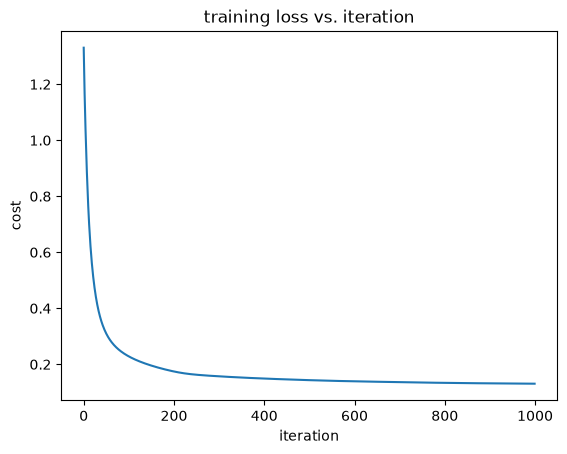

In [27]:
# plot cost vs. iterations
plt.plot(np.arange(len(J_history)), J_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("training loss vs. iteration")
plt.show()

In [28]:
# Training cost
preds = (sigmoid(scaled_train_X @ w + b) >= 0.5).astype(int)
print((preds == train_y).mean())

0.9552285013455264


In [29]:
# Test cost
preds = (sigmoid(scaled_test_X @ w + b) >= 0.5).astype(int)
print((preds == test_y).mean())

0.7395315826827538


In [30]:
le.classes_

array(['anomaly', 'normal'], dtype=object)

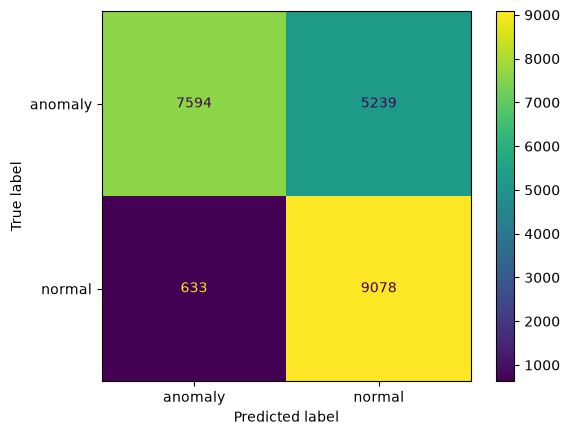

In [31]:
# Creating a confusion matrix on the test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#tn, fp, fn, tp = metrics.confusion_matrix(test_y, preds).ravel().tolist()
# sklean LabelEncoder encodes a category by alphabetic order
# thus, anomalies are encoded as 0 and normal traffic as 1
cm = confusion_matrix(test_y, preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot()
# In our context:
# True Positive is a correctly classified n
# False Positive: normal traffic labeled as an attack
# True Negative: 